# Layer Probing — *where* does Chronos-Bolt eat a single signal?

Pick **one** generated signal, extract every quantity that defines it (from the patch-tokenisation
formula reference), feed it to Chronos-Bolt-Tiny, and trace **stage by stage** what each layer keeps
versus loses. Stages, in order:

`input → instance-scaling → patching → pre-embedding → post-embedding → enc0..3 → dec0..3 → decoder-output`

The signal carries a *known* injected tone (`cpp` or `hz`), so we know exactly which frequency to follow.

## 1 · Setup — load the model and discover its architecture

In [1]:
import torch, os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from chronos import BaseChronosPipeline

np.random.seed(42); torch.manual_seed(42)
pd.set_option("display.max_colwidth", 80)

OUT = Path("../outputs/"); OUT.mkdir(parents=True, exist_ok=True)
SIGNALS_DIR = "../data/synthetic/signals/"

pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-tiny", device_map="cpu")
model = pipeline.model
cfg = model.config.chronos_config

P        = cfg["input_patch_size"]
S_DEF    = cfg["input_patch_stride"]
PRED_LEN = cfg["prediction_length"]
D_MODEL  = cfg.get("d_model", model.config.d_model)
N_ENC    = len(model.encoder.block)
N_DEC    = len(model.decoder.block)
print(f"P={P}  S={S_DEF}  pred_len={PRED_LEN}  d_model={D_MODEL}  encoder_blocks={N_ENC}  decoder_blocks={N_DEC}")

/Users/federicosabbadini/Library/Mobile Documents/com~apple~CloudDocs/Workspaces/gitHub-workspace/patchAliasing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


P=16  S=16  pred_len=64  d_model=256  encoder_blocks=4  decoder_blocks=4


## 2 · Choose one signal
Set `PICK` to a filename substring (e.g. `"cpp1_"`) or an integer index.

In [2]:
files = sorted(f for f in os.listdir(SIGNALS_DIR) if f.endswith(".npy"))
print(f"{len(files)} signals available. First few:")
for f in files[:6]: print("  ", f)

PICK = "cpp1_"                      # <-- change me (substring or int index)
if isinstance(PICK, int):
    chosen = files[PICK]
else:
    chosen = next(f for f in files if PICK in f)

signal = np.load(os.path.join(SIGNALS_DIR, chosen)).astype(float).ravel()
print(f"\nChosen: {chosen}\nlength={len(signal)}  std={signal.std():.3f}")

48 signals available. First few:
   KernelSynth_J5_l_syn512_fs256_jitter1e-06__cpp0_amp1.1.npy
   KernelSynth_J5_l_syn512_fs256_jitter1e-06__cpp0_amp1.5.npy
   KernelSynth_J5_l_syn512_fs256_jitter1e-06__cpp0_amp1.9.npy
   KernelSynth_J5_l_syn512_fs256_jitter1e-06__cpp0_amp1.95.npy
   KernelSynth_J5_l_syn512_fs256_jitter1e-06__cpp0_amp1.98.npy
   KernelSynth_J5_l_syn512_fs256_jitter1e-06__cpp1_amp0.25.npy

Chosen: KernelSynth_J5_l_syn512_fs256_jitter1e-06__cpp1_amp0.25.npy
length=512  std=1.014


## 3 · Probe the signal — every derived quantity

From the filename we read `fs`, the injected tone (`cpp` or `hz`), and `phase`. Everything else
follows from the formula reference:

`f = cpp·fs/P` · `T0 = fs/f = P/cpp` · `Δt_patch = P/fs` · `f_patch = fs/S` ·
`blind cpp = m·P/S` · stride-lock `S·f/fs ∈ ℤ` · within-patch redundancy `cpp ∈ ℤ`.

In [3]:
def parse_name(fname):
    """Read generator + injected-tone parameters out of a signal filename."""
    gen = "KernelSynth" if "kernelsynth" in fname.lower() else "TSMixup"
    grab = lambda pat, cast=float: (cast(re.search(pat, fname).group(1)) if re.search(pat, fname) else None)
    return dict(generator=gen,
                cpp=grab(r"_cpp([0-9.]+)"), hz=grab(r"_hz([0-9.]+)"),
                fs=grab(r"_fs([0-9]+)", int) or 256,
                phase=grab(r"_ph([0-9.]+)") or 0.0)

def injected_cpp(meta):
    """The tone's cycles-per-patch, whether it was specified in cpp or in Hz."""
    if meta["cpp"] is not None: return meta["cpp"]
    if meta["hz"]  is not None: return meta["hz"] * P / meta["fs"]
    return None

def derive(meta, S=S_DEF):
    fs  = meta["fs"]
    cpp = injected_cpp(meta)
    f   = cpp * fs / P if cpp is not None else None
    rows = [
        ("fs",        fs,                       "Hz",      "sampling frequency"),
        ("P",         P,                        "samples", "patch size"),
        ("S",         S,                        "samples", "stride"),
        ("cpp",       cpp,                       "cyc/patch","injected tone, cycles per patch"),
        ("f",         f,                         "Hz",      "tone frequency = cpp*fs/P"),
        ("T0",        (P/cpp) if cpp else None,  "samples", "tone period = fs/f = P/cpp"),
        ("T0_sec",    (1/f) if f else None,      "s",       "tone period in seconds = 1/f"),
        ("dt_patch",  P/fs,                      "s",       "patch duration = P/fs"),
        ("f_patch",   fs/S,                      "Hz",      "patch rate = fs/S"),
        ("nyquist",   fs/2,                      "Hz",      "fs/2"),
        ("stride_lock", (S*f/fs) if f else None, "",        "S*f/fs ; integer => identical patches"),
    ]
    return pd.DataFrame(rows, columns=["symbol", "value", "unit", "meaning"])

def classify(meta, S=S_DEF):
    cpp = injected_cpp(meta)
    if cpp is None: return "n/a", "no injected tone"
    f = cpp * meta["fs"] / P
    near_int = lambda v: abs(v - round(v)) < 1e-6
    stride_lock  = near_int(S * f / meta["fs"])     # S = m*T0  (identical consecutive patches)
    within_patch = near_int(cpp)                    # P = k*T0  (patch internally redundant)
    overlap = S < P
    if stride_lock and within_patch and not overlap: return "MAX",     "identical AND internally redundant patches"
    if stride_lock and not overlap:                  return "SEVERE",  "phase-locked: identical consecutive patches"
    if within_patch:                                 return "PARTIAL", "each patch internally redundant"
    if overlap:                                      return "SAFE",    "overlap keeps phase information"
    return "SAFE", "off-grid: not phase-locked"

meta = parse_name(chosen)
quant = derive(meta)
blind = [m * P / S_DEF for m in range(1, S_DEF // 2 + 1)]
cls, why = classify(meta)
print(f"generator={meta['generator']}  phase={meta['phase']:.3f} rad")
print(f"blind-spot cpp values (m*P/S): {blind}")
print(f"DEGENERACY CLASS: {cls}  —  {why}")
quant

generator=KernelSynth  phase=0.000 rad
blind-spot cpp values (m*P/S): [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
DEGENERACY CLASS: MAX  —  identical AND internally redundant patches


,symbol,value,unit,meaning
0,fs,256.0000,Hz,sampling frequency
1,P,16.0000,samples,patch size
2,S,16.0000,samples,stride
3,cpp,1.0000,cyc/patch,"injected tone, cycles per patch"
4,f,16.0000,Hz,tone frequency = cpp*fs/P
5,T0,16.0000,samples,tone period = fs/f = P/cpp
6,T0_sec,0.0625,s,tone period in seconds = 1/f
7,dt_patch,0.0625,s,patch duration = P/fs
8,f_patch,16.0000,Hz,patch rate = fs/S
9,nyquist,128.0000,Hz,fs/2


**Visualise the patch grid.** When the tone sits on an integer `cpp`, successive patch rows become identical — that is the structural-aliasing fingerprint, visible before the model even runs.

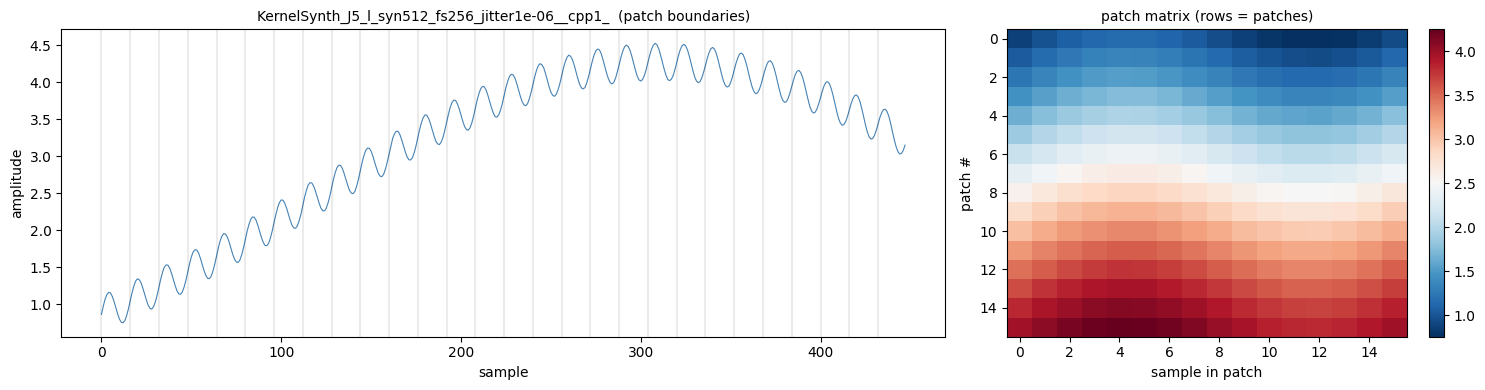

In [4]:
def cut_into_patches(x, P, S):
    return np.stack([x[i:i+P] for i in range(0, len(x) - P + 1, S)])

ctx = signal[:len(signal) - PRED_LEN]
patches = cut_into_patches(ctx, P, S_DEF)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(15, 4),
                             gridspec_kw=dict(width_ratios=[2, 1]))
a0.plot(ctx, lw=0.8, color="steelblue")
for b in range(0, len(ctx), S_DEF):
    a0.axvline(b, color="k", alpha=0.08)
a0.set_title(f"{chosen[:48]}  (patch boundaries)", fontsize=10)
a0.set_xlabel("sample"); a0.set_ylabel("amplitude")

im = a1.imshow(patches[:16], aspect="auto", cmap="RdBu_r")
a1.set_title("patch matrix (rows = patches)", fontsize=10)
a1.set_xlabel("sample in patch"); a1.set_ylabel("patch #")
fig.colorbar(im, ax=a1, fraction=0.046)
plt.tight_layout(); plt.show()

## 4 · Feed Chronos correctly and capture every stage

We forecast on `context = signal[:-PRED_LEN]` (so the last `PRED_LEN` samples are held out as truth).
Forward hooks record the activation at each module; for the pre-patch stages (`input`, `scaled`) we
form the equivalent patch matrix so every stage is comparable as a *(tokens × features)* matrix.

In [5]:
def as_matrix(t):
    """Detach a captured tensor (possibly tuple) to a 2D numpy matrix (tokens x features)."""
    if isinstance(t, tuple): t = t[0]
    a = t.detach().cpu().numpy()
    return a[0] if a.ndim == 3 else a          # drop batch dim

def forward_capture(context, stride=S_DEF):
    cap, handles = {}, []
    model.patch.patch_stride = stride

    def save(key, use_input=False):
        def hook(mod, inp, out):
            cap[key] = as_matrix(inp[0] if use_input else out)
        return hook

    # scaling, patching, embedding
    if hasattr(model, "instance_norm"):
        handles.append(model.instance_norm.register_forward_hook(save("scaled")))
    handles.append(model.patch.register_forward_hook(save("patched")))
    handles.append(model.input_patch_embedding.register_forward_hook(save("pre_embed", use_input=True)))
    handles.append(model.input_patch_embedding.register_forward_hook(save("post_embed")))
    # encoder / decoder blocks
    for k, blk in enumerate(model.encoder.block):
        handles.append(blk.register_forward_hook(save(f"enc{k}")))
    for k, blk in enumerate(model.decoder.block):
        handles.append(blk.register_forward_hook(save(f"dec{k}")))
    # decoder output, just before the final projection
    if hasattr(model, "output_patch_embedding"):
        handles.append(model.output_patch_embedding.register_forward_hook(save("dec_out", use_input=True)))

    x = torch.tensor(np.asarray(context, np.float32)).unsqueeze(0)
    with torch.no_grad():
        forecast = pipeline.predict(x, prediction_length=PRED_LEN)

    for h in handles: h.remove()
    model.patch.patch_stride = S_DEF

    # prepend the two pre-patch stages as patch matrices so all stages are comparable
    cap = {"input":  cut_into_patches(context, P, stride),
           "scaled": cut_into_patches(cap["scaled"].ravel(), P, stride) if "scaled" in cap
                     else cut_into_patches(context, P, stride),
           **cap}
    return forecast, cap

forecast, cap = forward_capture(ctx)
STAGES = ["input","scaled","patched","pre_embed","post_embed",
          *[f"enc{k}" for k in range(N_ENC)], *[f"dec{k}" for k in range(N_DEC)], "dec_out"]
STAGES = [s for s in STAGES if s in cap]
print("captured stages and shapes:")
for s in STAGES: print(f"  {s:11s} {cap[s].shape}")

captured stages and shapes:
  input       (28, 16)
  scaled      (1, 448)
  patched     (28, 16)
  pre_embed   (28, 32)
  post_embed  (28, 256)
  enc0        (29, 256)
  enc1        (29, 256)
  enc2        (29, 256)
  enc3        (29, 256)
  dec0        (1, 256)
  dec1        (1, 256)
  dec2        (1, 256)
  dec3        (1, 256)
  dec_out     (1, 256)


## 5 · What each layer keeps vs eats

Three per-stage metrics, all computed on this one signal's token sequence:

- **redundancy** = mean cosine between adjacent tokens. `→1` ⇒ consecutive tokens identical ⇒ the
  model cannot tell time steps apart (information eaten).
- **effective rank** = entropy-based rank of the token matrix. Collapsing ⇒ the sequence lives in
  fewer dimensions ⇒ representational capacity lost.
- **token spread** = std of token norms; near-zero ⇒ tokens indistinguishable.

In [6]:
def adjacent_cos(M):
    M = np.asarray(M, float)
    sims = [np.dot(M[i], M[i+1]) / (np.linalg.norm(M[i]) * np.linalg.norm(M[i+1]) + 1e-12)
            for i in range(len(M) - 1)]
    return float(np.mean(sims)) if sims else np.nan

def effective_rank(M):
    M = np.asarray(M, float); M = M - M.mean(0, keepdims=True)
    sv = np.linalg.svd(M, compute_uv=False); sv = sv[sv > 1e-12]
    if sv.size == 0: return 0.0
    p = sv / sv.sum(); return float(np.exp(-(p * np.log(p)).sum()))

def token_spread(M):
    return float(np.std(np.linalg.norm(np.asarray(M, float), axis=1)))

def stage_metrics(M):
    """Geometry is only meaningful with >=3 tokens; the decoder runs on 1 query token."""
    n = len(M)
    if n < 3:
        return dict(n_tokens=n, redundancy=np.nan, eff_rank=np.nan, token_spread=np.nan)
    return dict(n_tokens=n, redundancy=adjacent_cos(M),
                eff_rank=effective_rank(M), token_spread=token_spread(M))

prof = pd.DataFrame([{"stage": s, **stage_metrics(cap[s])} for s in STAGES])
prof   # NaN rows = too few tokens to be comparable (decoder side)

,stage,n_tokens,redundancy,eff_rank,token_spread
0,input,28,0.999968,1.196498,4.217842
1,scaled,1,NaN,NaN,NaN
2,patched,28,1.000000,0.000000,0.000000
3,pre_embed,28,0.993723,1.196498,1.327818
4,post_embed,28,0.992508,2.614762,0.135009
5,enc0,29,0.944744,6.555696,0.230490
6,enc1,29,0.929631,10.189772,0.450256
7,enc2,29,0.901563,13.730793,0.502806
8,enc3,29,0.820065,17.253357,0.577875
9,dec0,1,NaN,NaN,NaN


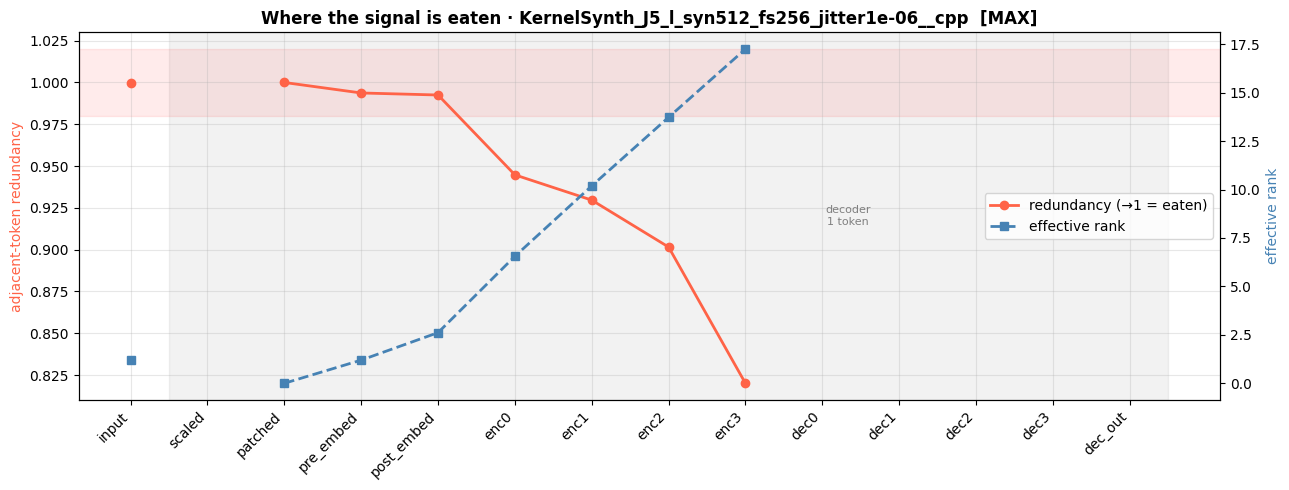

Across the encoder: redundancy 0.94→0.82 (falls), eff_rank 6.6→17.3 (rises)
=> tokeniser eats it; the encoder re-diversifies identical patches via positional encoding.


In [7]:
fig, ax = plt.subplots(figsize=(13, 5)); ax2 = ax.twinx()
xs = np.arange(len(STAGES))
ax.plot(xs, prof["redundancy"], "o-", color="tomato", lw=2, label="redundancy (→1 = eaten)")
ax2.plot(xs, prof["eff_rank"], "s--", color="steelblue", lw=2, label="effective rank")
ax.set_xticks(xs); ax.set_xticklabels(STAGES, rotation=45, ha="right")
# grey-out stages with too few tokens (decoder = 1 query token => geometry undefined)
few = prof["redundancy"].isna().values
if few.any():
    ax.axvspan(xs[few].min() - 0.5, xs[few].max() + 0.5, color="grey", alpha=0.10)
    ax.text(xs[few].mean(), 0.5, "decoder\n1 token", ha="center", va="center",
            fontsize=8, color="grey", transform=ax.get_xaxis_transform())
ax.set_ylabel("adjacent-token redundancy", color="tomato")
ax2.set_ylabel("effective rank", color="steelblue")
ax.axhspan(0.98, 1.02, color="red", alpha=0.08)
ax.set_title(f"Where the signal is eaten · {chosen[:46]}  [{cls}]", fontweight="bold")
l1, la1 = ax.get_legend_handles_labels(); l2, la2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, la1 + la2, loc="center right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "L1_layer_profile.png", dpi=140, bbox_inches="tight"); plt.show()

# quantify the two competing effects across the encoder
enc = [s for s in STAGES if s.startswith("enc")]
if len(enc) >= 2:
    pi = prof.set_index("stage")
    r0, r1 = pi.loc[enc[0], "redundancy"], pi.loc[enc[-1], "redundancy"]
    k0, k1 = pi.loc[enc[0], "eff_rank"],   pi.loc[enc[-1], "eff_rank"]
    print(f"Across the encoder: redundancy {r0:.2f}→{r1:.2f} (falls), eff_rank {k0:.1f}→{k1:.1f} (rises)")
    print("=> tokeniser eats it; the encoder re-diversifies identical patches via positional encoding.")

## 6 · Spectral round-trip — what survives input → forecast

This is also the only meaningful **decoder** read-out: the decoder is a single token, so its forecast
*is* its output. Compare the **input** spectrum with the **forecast** spectrum.

Caution on MAE: a tone on an integer `cpp` makes the signal *trivially periodic*, so forecast MAE is
usually **low** even though the representation is maximally degenerate. Low MAE is therefore **not**
evidence against aliasing — the harm is representational (§5), and the injected frequency usually
survives in the forecast spectrum (matching Pagani et al.: frequency stays accessible in the encoder).

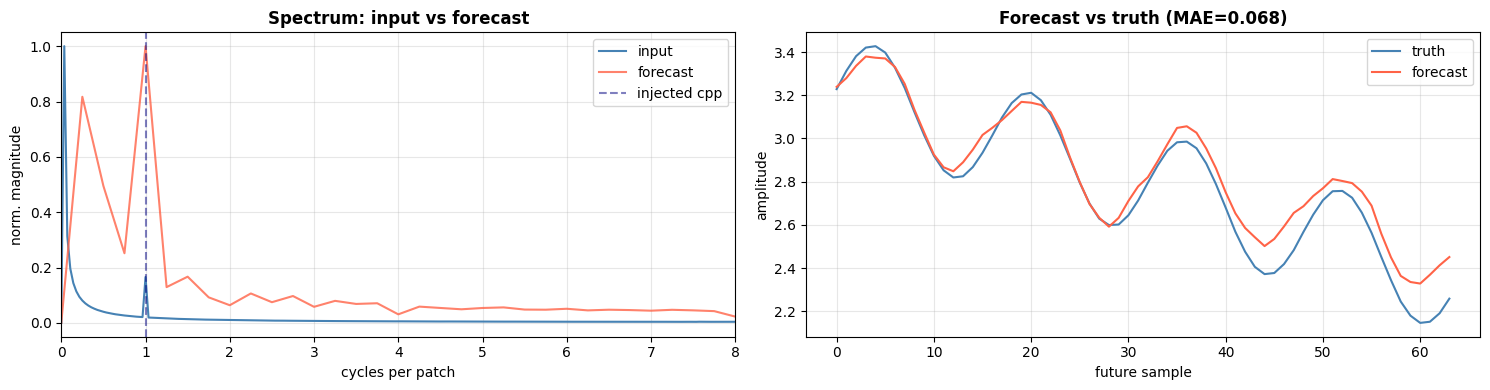

In [8]:
pred = forecast[0].median(dim=0).values.numpy()
truth = signal[len(ctx):len(ctx) + PRED_LEN]

def spectrum_cpp(x):
    x = np.asarray(x, float) - np.mean(x)
    mag = np.abs(np.fft.rfft(x))
    return np.fft.rfftfreq(len(x)) * P, mag

cin, min_ = spectrum_cpp(ctx)
cout, mout = spectrum_cpp(pred)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(15, 4))
a0.plot(cin, min_ / (min_.max() + 1e-9), color="steelblue", label="input")
a0.plot(cout, mout / (mout.max() + 1e-9), color="tomato", alpha=0.8, label="forecast")
if injected_cpp(meta): a0.axvline(injected_cpp(meta), color="navy", ls="--", alpha=0.5, label="injected cpp")
a0.set_xlim(0, P/2); a0.set_xlabel("cycles per patch"); a0.set_ylabel("norm. magnitude")
a0.set_title("Spectrum: input vs forecast", fontweight="bold"); a0.legend(); a0.grid(alpha=0.3)

a1.plot(truth, color="steelblue", label="truth")
a1.plot(pred, color="tomato", label="forecast")
a1.set_xlabel("future sample"); a1.set_ylabel("amplitude")
a1.set_title(f"Forecast vs truth (MAE={np.mean(np.abs(truth-pred)):.3f})", fontweight="bold")
a1.legend(); a1.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "L1_spectral_roundtrip.png", dpi=140, bbox_inches="tight"); plt.show()

## 7 · Verdict

In [9]:
valid = prof.dropna(subset=["redundancy"])
collapse = valid.loc[valid["redundancy"].idxmax()]
c = injected_cpp(meta)
print(f"Signal           : {chosen}")
print(f"Injected tone    : cpp={c}  (f={c*meta['fs']/P:.1f} Hz)" if c else "Injected tone    : none")
print(f"Degeneracy class : {cls}  ({why})")
print(f"Most redundant   : '{collapse['stage']}'  (redundancy={collapse['redundancy']:.3f})")
print(f"Forecast MAE     : {np.mean(np.abs(truth - pred)):.3f}")
print()
print("Reading:")
print(" - redundancy is already ~max at 'patched' => loss is ARCHITECTURAL (tokenisation),")
print("   present before any learned layer.")
print(" - it then FALLS through the encoder while effective rank RISES => the encoder partially")
print("   repairs the degeneracy using positional information.")
print(" - the decoder (1 token) cannot be probed geometrically; judge it by the round-trip.")
print(f" - low MAE despite class [{cls}] is expected: a phase-locked signal is trivially periodic.")

Signal           : KernelSynth_J5_l_syn512_fs256_jitter1e-06__cpp1_amp0.25.npy
Injected tone    : cpp=1.0  (f=16.0 Hz)
Degeneracy class : MAX  (identical AND internally redundant patches)
Most redundant   : 'patched'  (redundancy=1.000)
Forecast MAE     : 0.068

Reading:
 - redundancy is already ~max at 'patched' => loss is ARCHITECTURAL (tokenisation),
   present before any learned layer.
 - it then FALLS through the encoder while effective rank RISES => the encoder partially
   repairs the degeneracy using positional information.
 - the decoder (1 token) cannot be probed geometrically; judge it by the round-trip.
 - low MAE despite class [MAX] is expected: a phase-locked signal is trivially periodic.
